In [ ]:
def adf_test(series, maxlag=None):
    result = adfuller(series.dropna(), maxlag=maxlag, autolag='AIC')
    return {
        "stat": result[0],
        "pvalue": result[1],
        "lags": result[2]
    }

def kpss_test(series, regression="c", nlags="auto"):
    stat, pvalue, lags, _ = kpss(series.dropna(), regression=regression, nlags=nlags)
    return {
        "stat": stat,
        "pvalue": pvalue,
        "lags": lags
    }

def integration_diagnosis(series, name):
    adf = adf_test(series)
    kpss = kpss_test(series)

    return pd.Series({
        "ADF stat": adf["stat"],
        "ADF p-value": adf["pvalue"],
        "KPSS stat": kpss["stat"],
        "KPSS p-value": kpss["pvalue"],
        "Conclusion": (
            "I(0)" if (adf["pvalue"] < 0.05 and kpss["pvalue"] > 0.05)
            else "I(1)" if (adf["pvalue"] > 0.05 and kpss["pvalue"] < 0.05)
            else "Inconclusive"
        )
    }, name=name)

# -----------------------------
# Sample splits
# -----------------------------

y = df["i"]  

y_full = y.copy()
y_pre_2019 = y[y.index < "2019-01-01"]
y_post_2019 = y[y.index >= "2019-01-01"]

# -----------------------------
# Run tests
# -----------------------------

results = pd.concat([
    integration_diagnosis(y_full, "Full sample"),
    integration_diagnosis(y_pre_2019, "Pre-2019"),
    integration_diagnosis(y_post_2019, "Post-2019")
], axis=1).T

results

,ADF stat,ADF p-value,KPSS stat,KPSS p-value,Conclusion
Full sample,-3.772189,0.003205,0.390883,0.081085,I(0)
Pre-2019,-3.334529,0.013404,0.352402,0.097672,I(0)
Post-2019,-1.740159,0.410549,0.40046,0.076957,Inconclusive


The Post-2019 data are not informative enough to clearly discriminate between stationarity and a unit root

In [ ]:
# Compute AR coefficients and cumulative response (MA(∞) and its cumulative sum)
p = int(ar6_model.k_ar) if hasattr(ar6_model, 'k_ar') else 6  # number of lags
ar_coefs = ar6_model.params.iloc[1:1+p].values  
sum_ar_coefs = ar_coefs.sum()

# Convert AR to MA(∞) and compute cumulative response
ar_poly = [1] + list(-ar_coefs)  # AR polynomial: 1 - φ1 L - ... - φp L^p
psi = arma2ma(ar=ar_poly, ma=[1], lags=200)  # increase lags for better long-run approx
cum_response = np.cumsum(psi)  # cumulative impulse response to a unit shock

# Summary / printing
print(f"AR coefficients (phi1..phip): {ar_coefs}")
print(f"Sum of AR coefficients (SARC): {sum_ar_coefs:.6f}")
print(f"Approx. long-run cumulative response (sum psi up to {len(psi)-1}): {cum_response[-1]:.6f}")

# Make results available for later cells
ar_response_summary = {
    'p': p,
    'ar_coefs': ar_coefs,
    'sum_ar_coefs': sum_ar_coefs,
    'psi': psi,
    'cum_response': cum_response,
    'long_run_approx': float(cum_response[-1])
}

AR coefficients (phi1..phip): [0.26348279 0.02243711 0.0878766  0.0653802  0.06151327 0.24660801]
Sum of AR coefficients (SARC): 0.747298
Approx. long-run cumulative response (sum psi up to 199): 3.957229


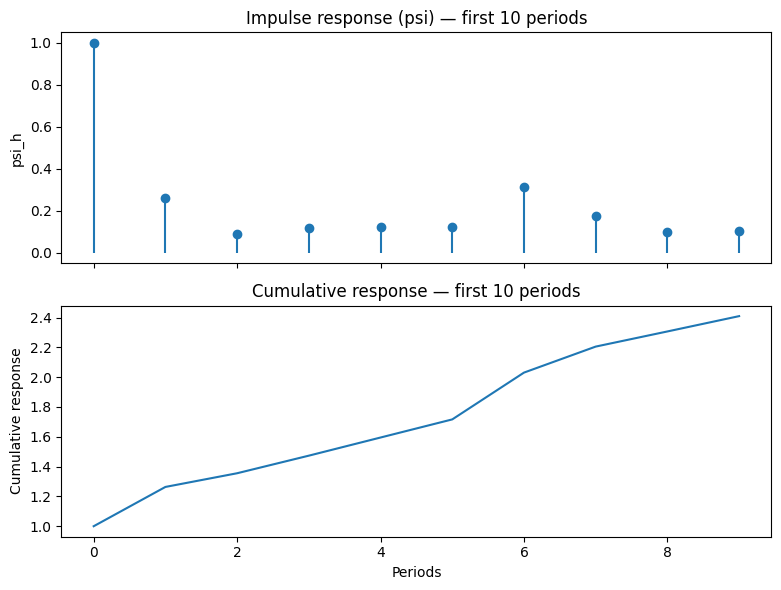

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

n_plot = 10  # number of periods to plot

# Impulse response (psi)
axes[0].stem(range(n_plot), irf[:n_plot], basefmt=' ')
axes[0].set_title('Impulse response (psi) — first 10 periods')
axes[0].set_ylabel('psi_h')

# Cumulative response (match same horizon)
cum_response_plot = np.cumsum(irf[:n_plot])
axes[1].plot(range(n_plot), cum_response_plot)
axes[1].set_title('Cumulative response — first 10 periods')
axes[1].set_ylabel('Cumulative response')
axes[1].set_xlabel('Periods')

plt.tight_layout()
